# 09. Hyperparameter Tuning and Model Selection
@Shengli (Bruce) Jiang, University of South Carolina

Can the first 100 battery cycles predict the eventual lifetime?

1. Build features from early measurements
2. Select Ridge and Lasso strength using validation data
3. Compare manual cross-validation with GridSearchCV
4. Preview how transforming the target changes predictions


## Running the notebook

**Use the battery dataset uploaded with this lecture.** Keep the supplied `data/battery/` folder beside this notebook. It contains `features.csv`, `capacity_examples.csv`, and `discharge_curves_b2c29.csv`. No data download is needed.

Run from top to bottom using NumPy, pandas, Matplotlib, and scikit-learn (1.4 or newer). Restart the kernel and run all cells to check your work.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

data = pd.read_csv("data/battery/features.csv")
capacity = pd.read_csv("data/battery/capacity_examples.csv")

feature_columns = [
    "log10_var_dQ100_10",
    "log10_abs_min_dQ100_10",
    "mean_dQ100_10_Ah",
    "max_Qdlin_cycle2_Ah",
    "max_Qdlin_cycle100_minus2_Ah",
    "max_Qdlin_slope_cycles2_100_Ah_per_cycle",
]
X = data[feature_columns].to_numpy()
y = data["cycle_life"].to_numpy()

print("Number of batteries:", X.shape[0])
print("Number of features:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)
data.head()


Number of batteries: 124
Number of features: 6
X shape: (124, 6)
y shape: (124,)


,cell_id,split,source_cell_index_1based,batch,cycle_life,log10_cycle_life,log10_var_dQ100_10,log10_abs_min_dQ100_10,mean_dQ100_10_Ah,max_Qdlin_cycle2_Ah,max_Qdlin_cycle100_minus2_Ah,max_Qdlin_slope_cycles2_100_Ah_per_cycle
0,b1c1,train,1,1,2160,3.334454,-5.013824,-1.958607,-0.004099,1.0612,0.0035,-0.000013
1,b1c3,train,2,1,1434,3.156549,-4.442223,-1.722162,-0.007455,1.0639,0.0025,-0.021367
2,b1c5,train,3,1,1074,3.031004,-4.178592,-1.598944,-0.011075,1.0598,-0.0002,-0.000028
3,b1c7,train,4,1,870,2.939519,-3.813009,-1.417596,-0.016647,1.0785,-0.0035,-0.000065
4,b1c11,train,5,1,788,2.896526,-4.146441,-1.625435,-0.008378,1.0345,0.0047,0.000008


## 1. One row represents one battery

The dataset contains 124 commercial LFP/graphite batteries tested under different fast-charging conditions. `cycle_life` is the released total lifetime at 80% of nominal capacity: $0.8\times1.1=0.88$ Ah. At cycle 100, remaining lifetime would be `cycle_life - 100`.

Our six features use only cycles 2–100. Cell IDs, split labels, and the target's logarithm are **not input features**.

Source: [Severson et al., Nature Energy (2019)](https://doi.org/10.1038/s41560-019-0356-8), with curves from the [authors' compact release](https://github.com/petermattia/revisit-severson-et-al). This lesson uses a simplified feature set and an adapted split, so it is not an exact reproduction of the paper.


### 1.1 Similar early capacity, different lifetimes

These are two measured training batteries. Solid curves show the available measurements; dashed curves show later measurements, not predictions. Cycle 1 is omitted because one source record has zero capacity there.


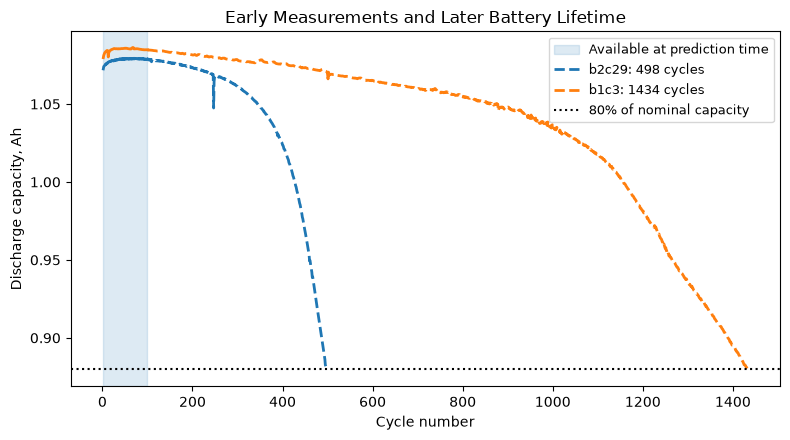

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axvspan(1, 100, color="C0", alpha=0.15, label="Available at prediction time")

for color, cell_id in zip(["C0", "C1"], ["b2c29", "b1c3"]):
    life = data.loc[data["cell_id"].eq(cell_id), "cycle_life"].iloc[0]
    history = capacity.loc[capacity["cell_id"].eq(cell_id) & capacity["cycle"].between(2, life)]
    cycle = history["cycle"].to_numpy()
    q = history["discharge_capacity_Ah"].to_numpy()
    ax.plot(cycle[cycle <= 100], q[cycle <= 100], color=color, linewidth=2)
    ax.plot(cycle[cycle >= 100], q[cycle >= 100], "--", color=color, linewidth=2,
            label=f"{cell_id}: {life:.0f} cycles")

ax.axhline(0.88, color="black", linestyle=":", label="80% of nominal capacity")
ax.set(xlabel="Cycle number", ylabel="Discharge capacity, Ah",
       title="Early Measurements and Later Battery Lifetime")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


## 2. Features summarize the early discharge curves

$Q_c(V)$ is the cumulative discharged charge when the battery reaches voltage $V$ in cycle $c$. The curves share 1,000 interpolated voltage points from 3.6 to 2.0 V.

Define $\Delta Q(V)=Q_{100}(V)-Q_{10}(V)$ and $M_c=\max_V Q_c(V)$.

| Feature | Calculation | Meaning |
| :-- | :-- | :-- |
| `log10_var_dQ100_10` | $\log_{10}[\mathrm{Var}(\Delta Q)]$ | Variation of the change across voltage |
| `log10_abs_min_dQ100_10` | $\log_{10}[\mathrm{abs}(\min\Delta Q)]$ | Magnitude of the most negative change, when the minimum is negative |
| `mean_dQ100_10_Ah` | Mean of $\Delta Q$ | Average signed change, Ah |
| `max_Qdlin_cycle2_Ah` | $M_2$ | Early capacity level, Ah |
| `max_Qdlin_cycle100_minus2_Ah` | $M_{100}-M_2$ | Net capacity change, Ah |
| `max_Qdlin_slope_cycles2_100_Ah_per_cycle` | Fitted slope of $M_c$ versus $c$ | Early trend, Ah/cycle |

The first two columns already contain logarithms. Do not take their logarithms again.


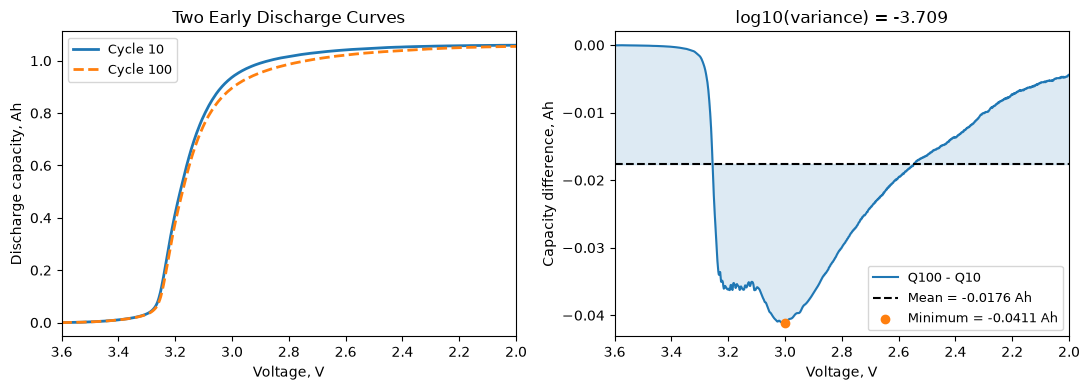

In [3]:
# Columns represent cycles 2-100; column 8 is cycle 10.
Q = pd.read_csv("data/battery/discharge_curves_b2c29.csv", header=None).to_numpy()
voltage = np.linspace(3.6, 2.0, Q.shape[0])
Q10, Q100 = Q[:, 8], Q[:, 98]
delta_Q = Q100 - Q10
variance = np.var(delta_Q, ddof=1)
minimum_index = np.argmin(delta_Q)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(voltage, Q10, linewidth=2, label="Cycle 10")
ax[0].plot(voltage, Q100, "--", linewidth=2, label="Cycle 100")
ax[0].set(xlabel="Voltage, V", ylabel="Discharge capacity, Ah", title="Two Early Discharge Curves")

ax[1].plot(voltage, delta_Q, color="C0", label="Q100 - Q10")
ax[1].axhline(delta_Q.mean(), color="black", linestyle="--", label=f"Mean = {delta_Q.mean():.4f} Ah")
ax[1].fill_between(voltage, delta_Q, delta_Q.mean(), color="C0", alpha=0.15)
ax[1].scatter(voltage[minimum_index], delta_Q[minimum_index], color="C1", zorder=3,
              label=f"Minimum = {delta_Q.min():.4f} Ah")
ax[1].set(xlabel="Voltage, V", ylabel="Capacity difference, Ah",
          title=f"log10(variance) = {np.log10(variance):.3f}")
for axis in ax:
    axis.set_xlim(3.6, 2.0)
    axis.legend(fontsize=9)
fig.tight_layout()
plt.show()


Variance measures deviations from the mean; the minimum picks one voltage location; the mean retains the sign of the average change. These describe different aspects of the same curve.

### 2.1 Capacity level, endpoint change, and fitted trend

The endpoint difference uses two cycles. The fitted slope uses all 99 cycle maxima, including the initial rise and later fall.


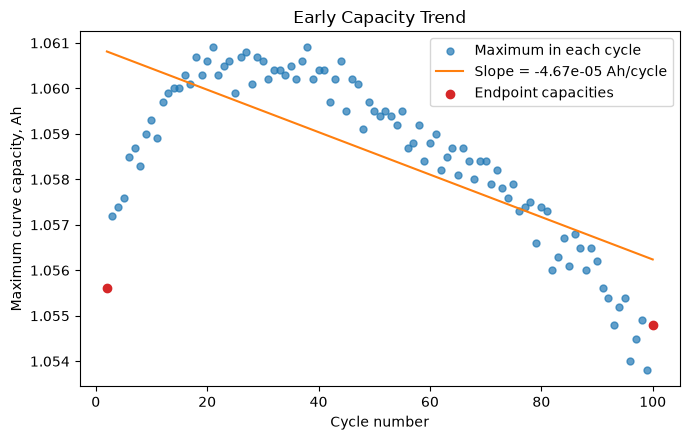

,Calculated,Supplied CSV
log10_var_dQ100_10,-3.708502,-3.708502
log10_abs_min_dQ100_10,-1.386264,-1.386264
mean_dQ100_10_Ah,-0.017622,-0.017622
max_Qdlin_cycle2_Ah,1.055600,1.055600
max_Qdlin_cycle100_minus2_Ah,-0.000800,-0.000800
max_Qdlin_slope_cycles2_100_Ah_per_cycle,-0.000047,-0.000047


In [4]:
cycles = np.arange(2, 101)
max_capacity = Q.max(axis=0)
slope, intercept = np.polyfit(cycles, max_capacity, 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(cycles, max_capacity, s=25, alpha=0.7, label="Maximum in each cycle")
ax.plot(cycles, slope * cycles + intercept, color="C1", label=f"Slope = {slope:.2e} Ah/cycle")
ax.scatter([2, 100], max_capacity[[0, -1]], color="C3", zorder=3, label="Endpoint capacities")
ax.set(xlabel="Cycle number", ylabel="Maximum curve capacity, Ah", title="Early Capacity Trend")
ax.legend()
fig.tight_layout()
plt.show()

calculated = [np.log10(variance), np.log10(abs(delta_Q.min())), delta_Q.mean(),
              max_capacity[0], max_capacity[-1] - max_capacity[0], slope]
supplied = data.loc[data["cell_id"].eq("b2c29"), feature_columns].iloc[0].to_numpy(dtype=float)
display(pd.DataFrame({"Calculated": calculated, "Supplied CSV": supplied}, index=feature_columns))


## 3. Training, validation, and test have different jobs

For this lesson, the released `primary_test` group becomes validation. The `secondary_test` group remains the final test set.

| Role | Batteries | Use |
| :-- | --: | :-- |
| Training | 41 | Fit coefficients and the scaler |
| Validation | 43 | Select hyperparameters |
| Final test | 40 | Evaluate the selected procedure |

Later, cross-validation uses all **84 development batteries** (training + validation). The final 40 batteries stay separate throughout. Keep every measurement from one battery in the same set.


In [5]:
train = data["split"].eq("train").to_numpy()
val = data["split"].eq("primary_test").to_numpy()
test = data["split"].eq("secondary_test").to_numpy()
dev = train | val

X_train, y_train = X[train], y[train]
X_val, y_val = X[val], y[val]
X_dev, y_dev = X[dev], y[dev]
X_test, y_test = X[test], y[test]

for name, x_part, y_part in [("Training", X_train, y_train), ("Validation", X_val, y_val),
                            ("Development", X_dev, y_dev), ("Test", X_test, y_test)]:
    print(f"{name}: X {x_part.shape}, y {y_part.shape}")


Training: X (41, 6), y (41,)
Validation: X (43, 6), y (43,)
Development: X (84, 6), y (84,)
Test: X (40, 6), y (40,)


### 3.1 Standardize using training data only

Each feature is centered and divided by its training standard deviation. Validation uses these same learned values. Scaling prevents feature units from determining the penalty strength.


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


## 4. Select Ridge strength using validation error

Fit one model for each alpha. Training error describes the fitted samples; validation error guides selection. All errors below are measured in cycles.


Best Ridge alpha: 0.0001
Validation RMSE: 153.08 cycles


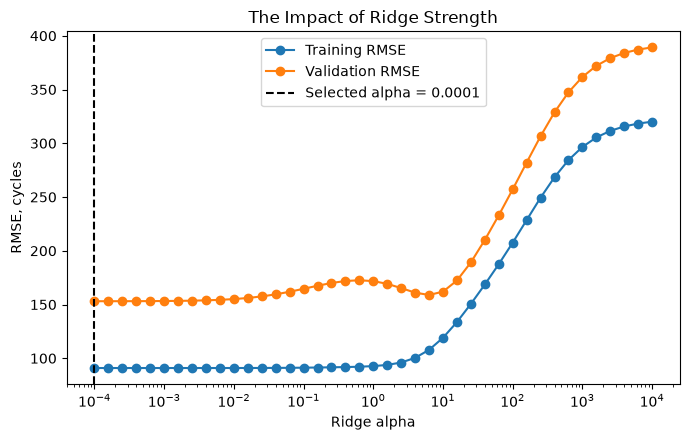

In [7]:
alpha_values = np.logspace(-4, 4, 41)
ridge_train_rmse, ridge_val_rmse = [], []

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    ridge_train_rmse.append(root_mean_squared_error(y_train, ridge.predict(X_train_scaled)))
    ridge_val_rmse.append(root_mean_squared_error(y_val, ridge.predict(X_val_scaled)))

ridge_alpha = alpha_values[np.argmin(ridge_val_rmse)]
print("Best Ridge alpha:", ridge_alpha)
print(f"Validation RMSE: {min(ridge_val_rmse):.2f} cycles")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(alpha_values, ridge_train_rmse, "o-", label="Training RMSE")
ax.semilogx(alpha_values, ridge_val_rmse, "o-", label="Validation RMSE")
ax.axvline(ridge_alpha, color="black", linestyle="--", label=f"Selected alpha = {ridge_alpha:.4g}")
ax.set(xlabel="Ridge alpha", ylabel="RMSE, cycles", title="The Impact of Ridge Strength")
ax.legend()
fig.tight_layout()
plt.show()


The low-alpha region is nearly flat: small penalties approach ordinary linear regression. A boundary minimum does not automatically require a wider grid. Large penalties eventually underfit.

## 5. Repeat the selection with Lasso

Lasso can set coefficients exactly to zero. Its alpha is not numerically comparable to Ridge alpha because their penalties and objective scaling differ.


Best Lasso alpha: 19.95262314968883
Validation RMSE: 148.90 cycles


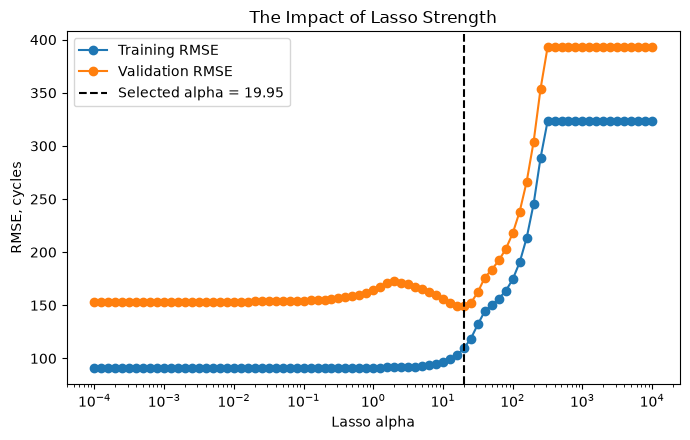

In [8]:
lasso_alphas = np.logspace(-4, 4, 81)
lasso_train_rmse, lasso_val_rmse = [], []

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, max_iter=100000).fit(X_train_scaled, y_train)
    lasso_train_rmse.append(root_mean_squared_error(y_train, lasso.predict(X_train_scaled)))
    lasso_val_rmse.append(root_mean_squared_error(y_val, lasso.predict(X_val_scaled)))

lasso_alpha = lasso_alphas[np.argmin(lasso_val_rmse)]
print("Best Lasso alpha:", lasso_alpha)
print(f"Validation RMSE: {min(lasso_val_rmse):.2f} cycles")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(lasso_alphas, lasso_train_rmse, "o-", label="Training RMSE")
ax.semilogx(lasso_alphas, lasso_val_rmse, "o-", label="Validation RMSE")
ax.axvline(lasso_alpha, color="black", linestyle="--", label=f"Selected alpha = {lasso_alpha:.4g}")
ax.set(xlabel="Lasso alpha", ylabel="RMSE, cycles", title="The Impact of Lasso Strength")
ax.legend()
fig.tight_layout()
plt.show()


### 5.1 Refit after selecting alpha

Fit a new scaler and each selected model on all 84 development batteries. We will report test results together at the end, after specifying all examples.


In [9]:
final_scaler = StandardScaler()
X_dev_scaled = final_scaler.fit_transform(X_dev)

ridge_final = Ridge(alpha=ridge_alpha).fit(X_dev_scaled, y_dev)
lasso_final = Lasso(alpha=lasso_alpha, max_iter=100000).fit(X_dev_scaled, y_dev)
print("Nonzero Lasso coefficients:", np.count_nonzero(lasso_final.coef_))


Nonzero Lasso coefficients: 4


## 6. Manual five-fold cross-validation

Instead of relying on one validation group, rotate the 84 development batteries through five folds. Each battery is validation once and fitting four times. Reuse the same folds for every candidate.


Fold 1: 67 fitting, 17 validation
Fold 2: 67 fitting, 17 validation
Fold 3: 67 fitting, 17 validation
Fold 4: 67 fitting, 17 validation
Fold 5: 68 fitting, 16 validation


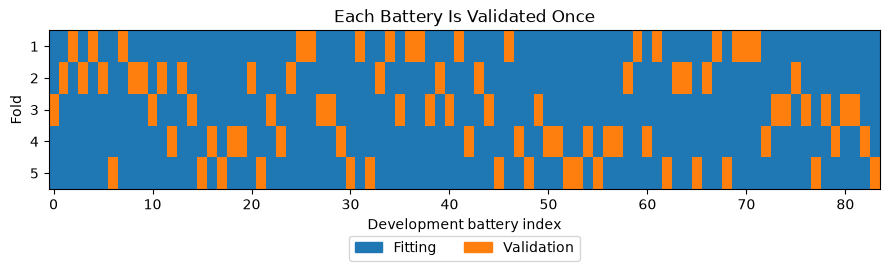

In [10]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

cv = KFold(n_splits=5, shuffle=True, random_state=26)
folds = list(cv.split(X_dev))
fold_map = np.zeros((5, len(y_dev)))

for fold, (fit_index, val_index) in enumerate(folds):
    fold_map[fold, val_index] = 1
    print(f"Fold {fold + 1}: {len(fit_index)} fitting, {len(val_index)} validation")

fig, ax = plt.subplots(figsize=(9, 3))
ax.imshow(fold_map, aspect="auto", interpolation="nearest", cmap=ListedColormap(["C0", "C1"]))
ax.set(xlabel="Development battery index", ylabel="Fold", title="Each Battery Is Validated Once")
ax.set_yticks(range(5), labels=range(1, 6))
ax.legend(handles=[Patch(color="C0", label="Fitting"), Patch(color="C1", label="Validation")],
          loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)
fig.tight_layout()
plt.show()


### 6.1 Follow one alpha through the five folds

Fit a new scaler using only the fitting portion of each fold. A scaler fitted on all 84 batteries before this loop would leak validation information.


In [11]:
fold_rmse = []
for fold, (fit_index, val_index) in enumerate(folds, start=1):
    fold_scaler = StandardScaler()
    X_fit = fold_scaler.fit_transform(X_dev[fit_index])
    X_fold_val = fold_scaler.transform(X_dev[val_index])
    model = Lasso(alpha=1.0, max_iter=100000).fit(X_fit, y_dev[fit_index])
    score = root_mean_squared_error(y_dev[val_index], model.predict(X_fold_val))
    fold_rmse.append(score)
    print(f"Fold {fold}: RMSE = {score:.2f} cycles")

print(f"Mean validation RMSE: {np.mean(fold_rmse):.2f} cycles")


Fold 1: RMSE = 120.62 cycles
Fold 2: RMSE = 78.45 cycles
Fold 3: RMSE = 111.75 cycles
Fold 4: RMSE = 162.50 cycles
Fold 5: RMSE = 185.64 cycles
Mean validation RMSE: 131.79 cycles


### 6.2 Compare alpha values on the same folds

The outer loop changes alpha; the inner loop changes the validation fold. Select the lowest mean validation RMSE.


In [12]:
cv_alphas = np.logspace(-4, 4, 81)
cv_train_rmse = np.zeros((len(cv_alphas), len(folds)))
cv_val_rmse = np.zeros_like(cv_train_rmse)

for i, alpha in enumerate(cv_alphas):
    for j, (fit_index, val_index) in enumerate(folds):
        fold_scaler = StandardScaler()
        X_fit = fold_scaler.fit_transform(X_dev[fit_index])
        X_fold_val = fold_scaler.transform(X_dev[val_index])
        model = Lasso(alpha=alpha, max_iter=100000).fit(X_fit, y_dev[fit_index])
        cv_train_rmse[i, j] = root_mean_squared_error(y_dev[fit_index], model.predict(X_fit))
        cv_val_rmse[i, j] = root_mean_squared_error(y_dev[val_index], model.predict(X_fold_val))

mean_cv_rmse = cv_val_rmse.mean(axis=1)
std_cv_rmse = cv_val_rmse.std(axis=1, ddof=1)
manual_alpha = cv_alphas[np.argmin(mean_cv_rmse)]
print("Best CV alpha:", manual_alpha)
print(f"Mean validation RMSE: {mean_cv_rmse.min():.2f} cycles")


Best CV alpha: 0.0001
Mean validation RMSE: 125.92 cycles


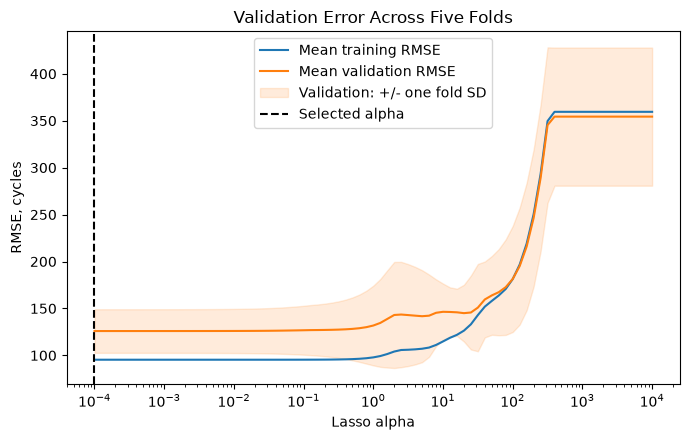

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(cv_alphas, cv_train_rmse.mean(axis=1), label="Mean training RMSE")
ax.semilogx(cv_alphas, mean_cv_rmse, color="C1", label="Mean validation RMSE")
ax.fill_between(cv_alphas, mean_cv_rmse - std_cv_rmse, mean_cv_rmse + std_cv_rmse,
                color="C1", alpha=0.15, label="Validation: +/- one fold SD")
ax.axvline(manual_alpha, color="black", linestyle="--", label="Selected alpha")
ax.set(xlabel="Lasso alpha", ylabel="RMSE, cycles", title="Validation Error Across Five Folds")
ax.legend()
fig.tight_layout()
plt.show()


The band shows variation across folds, not a confidence interval or a prediction interval. The selected alpha can differ from the single-validation result because the fitting and validation samples changed.

## 7. Stratification preserves existing proportions

This **toy example** has 12 LFP, 6 LCO, and 3 Li-S batteries. These are invented type labels; the real dataset above contains only LFP/graphite cells.

Stratification puts 4 LFP, 2 LCO, and 1 Li-S battery in each validation fold. It preserves the imbalance rather than removing it. For regression, the type labels can define the folds while lifetime remains the target.


In [14]:
battery_type = np.array(["LFP"] * 12 + ["LCO"] * 6 + ["Li-S"] * 3)
X_toy = np.arange(21).reshape(-1, 1)

for name, splitter in [("KFold", KFold(3, shuffle=True, random_state=26)),
                       ("StratifiedKFold", StratifiedKFold(3, shuffle=True, random_state=26))]:
    print(name)
    for fold, (_, val_index) in enumerate(splitter.split(X_toy, battery_type), start=1):
        types, counts = np.unique(battery_type[val_index], return_counts=True)
        print(f"Fold {fold}: {dict(zip(types.tolist(), counts.tolist()))}")


KFold
Fold 1: {'LCO': 4, 'LFP': 2, 'Li-S': 1}
Fold 2: {'LFP': 6, 'Li-S': 1}
Fold 3: {'LCO': 2, 'LFP': 4, 'Li-S': 1}
StratifiedKFold
Fold 1: {'LCO': 2, 'LFP': 4, 'Li-S': 1}
Fold 2: {'LCO': 2, 'LFP': 4, 'Li-S': 1}
Fold 3: {'LCO': 2, 'LFP': 4, 'Li-S': 1}


## 8. GridSearchCV automates the same calculation

A `Pipeline` fits the scaler inside each fold. GridSearchCV compares settings and then refits the best pipeline on all development data. Supply **unscaled inputs**.

`lasso__alpha` means the `alpha` parameter of the step named `lasso`. The score is negative RMSE because scikit-learn maximizes scores; negate it when reporting RMSE.


In [15]:
lasso_model = Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(max_iter=100000))])
lasso_parameters = {"lasso__alpha": cv_alphas}
lasso_search = GridSearchCV(lasso_model, lasso_parameters, cv=folds, scoring="neg_root_mean_squared_error")
lasso_search.fit(X_dev, y_dev)

print("Best alpha:", lasso_search.best_params_["lasso__alpha"])
print(f"Mean validation RMSE: {-lasso_search.best_score_:.2f} cycles")
print("Matches manual selection:", np.isclose(lasso_search.best_params_["lasso__alpha"], manual_alpha))


Best alpha: 0.0001
Mean validation RMSE: 125.92 cycles
Matches manual selection: True


### 8.1 Tune two Elastic Net hyperparameters

Alpha controls total penalty strength. `l1_ratio` controls the L1 share; a value of 1 gives Lasso. This grid has 41 × 6 = 246 combinations, requiring 1,230 fold fits plus one final refit.


In [16]:
elastic_model = Pipeline([("scaler", StandardScaler()), ("elastic", ElasticNet(max_iter=100000))])
elastic_parameters = {
    "elastic__alpha": np.logspace(-4, 4, 41),
    "elastic__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}
elastic_search = GridSearchCV(elastic_model, elastic_parameters, cv=folds, scoring="neg_root_mean_squared_error")
elastic_search.fit(X_dev, y_dev)

print("Best alpha:", elastic_search.best_params_["elastic__alpha"])
print("Best l1_ratio:", elastic_search.best_params_["elastic__l1_ratio"])
print(f"Mean validation RMSE: {-elastic_search.best_score_:.2f} cycles")


Best alpha: 0.0001
Best l1_ratio: 1.0
Mean validation RMSE: 125.92 cycles


## 9. Next lecture: the scale can change the model

The battery paper predicts **logarithmic lifetime**. Consider one input, already stored as $x=\log_{10}[\mathrm{Var}(\Delta Q)]$:

$$\text{Raw target:}\quad \hat y=a+bx,
\qquad
\text{Log target:}\quad \log_{10}\hat y=a+bx\;\Rightarrow\;\hat y=10^{a+bx}.$$

Both fits below standardize the same input. The log target changes the relationship on the cycle scale and emphasizes relative errors. Merely standardizing $y$ would not have this effect for ordinary linear regression.

This is a paper-inspired teaching example, not a claim of current state-of-the-art performance. We keep the same batteries and report every error back in cycles.


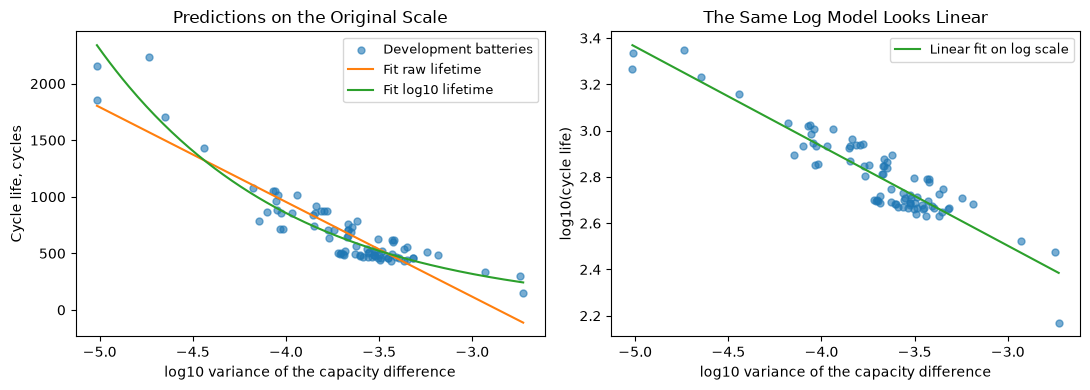

In [17]:
# One feature keeps the effect of the target transformation visible.
X_one_dev = X_dev[:, [0]]
raw_scaler = StandardScaler()
X_one_scaled = raw_scaler.fit_transform(X_one_dev)

raw_one = LinearRegression().fit(X_one_scaled, y_dev)
log_one = LinearRegression().fit(X_one_scaled, np.log10(y_dev))

x_plot = np.linspace(X_one_dev.min(), X_one_dev.max(), 200).reshape(-1, 1)
x_plot_scaled = raw_scaler.transform(x_plot)
raw_curve = raw_one.predict(x_plot_scaled)
log_curve = 10.0 ** log_one.predict(x_plot_scaled)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X_one_dev[:, 0], y_dev, s=25, alpha=0.6, label="Development batteries")
ax[0].plot(x_plot[:, 0], raw_curve, color="C1", label="Fit raw lifetime")
ax[0].plot(x_plot[:, 0], log_curve, color="C2", label="Fit log10 lifetime")
ax[0].set(ylabel="Cycle life, cycles", title="Predictions on the Original Scale")
ax[1].scatter(X_one_dev[:, 0], np.log10(y_dev), s=25, alpha=0.6)
ax[1].plot(x_plot[:, 0], log_one.predict(x_plot_scaled), color="C2", label="Linear fit on log scale")
ax[1].set(ylabel="log10(cycle life)", title="The Same Log Model Looks Linear")
for axis in ax:
    axis.set_xlabel("log10 variance of the capacity difference")
    axis.legend(fontsize=9)
fig.tight_layout()
plt.show()


### 9.1 Validate the transformation on the same folds

The one-feature models have no tuned penalty. Fit both within each fold and invert the log prediction **before** calculating RMSE. The transformation does not guarantee a better result for every model or dataset.


In [18]:
one_feature_scores = []
for fit_index, val_index in folds:
    fold_scaler = StandardScaler()
    X_fit = fold_scaler.fit_transform(X_one_dev[fit_index])
    X_fold_val = fold_scaler.transform(X_one_dev[val_index])
    raw_fit = LinearRegression().fit(X_fit, y_dev[fit_index])
    log_fit = LinearRegression().fit(X_fit, np.log10(y_dev[fit_index]))
    raw_pred = raw_fit.predict(X_fold_val)
    log_pred = 10.0 ** log_fit.predict(X_fold_val)
    one_feature_scores.append([root_mean_squared_error(y_dev[val_index], raw_pred),
                               root_mean_squared_error(y_dev[val_index], log_pred)])

one_feature_cv = np.mean(one_feature_scores, axis=0)
print(f"One feature, raw target CV RMSE: {one_feature_cv[0]:.2f} cycles")
print(f"One feature, log target CV RMSE: {one_feature_cv[1]:.2f} cycles")


One feature, raw target CV RMSE: 160.37 cycles
One feature, log target CV RMSE: 133.83 cycles


### 9.2 Apply the log target to the six-feature search

`TransformedTargetRegressor` performs the same steps automatically: fit on `log10(y)`, then return `10**prediction`. Its predictions and GridSearchCV scores remain in **cycles**. The input scaler stays inside the pipeline.

Use the same grid and folds as the raw-target Elastic Net. This comparison is included even if its test error increases.


In [19]:
log_elastic_model = TransformedTargetRegressor(
    regressor=elastic_model, func=np.log10, inverse_func=lambda z: 10.0 ** z,
)
log_parameters = {
    "regressor__elastic__alpha": np.logspace(-4, 4, 41),
    "regressor__elastic__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}
log_search = GridSearchCV(log_elastic_model, log_parameters, cv=folds, scoring="neg_root_mean_squared_error")
log_search.fit(X_dev, y_dev)

print("Best alpha:", log_search.best_params_["regressor__elastic__alpha"])
print("Best l1_ratio:", log_search.best_params_["regressor__elastic__l1_ratio"])
print(f"Raw-target Elastic Net CV RMSE: {-elastic_search.best_score_:.2f} cycles")
print(f"Log-target Elastic Net CV RMSE: {-log_search.best_score_:.2f} cycles")


Best alpha: 0.00630957344480193
Best l1_ratio: 1.0
Raw-target Elastic Net CV RMSE: 125.92 cycles
Log-target Elastic Net CV RMSE: 107.46 cycles


## 10. Evaluate the fixed models on the final test batteries

All features, transformations, and tuning grids are now specified. Each final fit uses the 84 development batteries. The results below are classroom comparisons; do not use this table to retune models and then describe the same test set as a new independent evaluation.

RMSE is measured in cycles. R2 compares squared error with predicting the test-set mean; it is not percentage accuracy.


In [20]:
X_test_scaled = final_scaler.transform(X_test)
X_one_test_scaled = raw_scaler.transform(X_test[:, [0]])

predictions = {
    "Ridge: single validation": ridge_final.predict(X_test_scaled),
    "Lasso: single validation": lasso_final.predict(X_test_scaled),
    "Lasso: five-fold CV": lasso_search.predict(X_test),
    "Elastic Net: five-fold CV": elastic_search.predict(X_test),
    "One feature: raw target": raw_one.predict(X_one_test_scaled),
    "One feature: log target": 10.0 ** log_one.predict(X_one_test_scaled),
    "Elastic Net: log target CV": log_search.predict(X_test),
}
test_results = pd.DataFrame([
    {"Model": name, "Test RMSE, cycles": root_mean_squared_error(y_test, prediction),
     "Test R2": r2_score(y_test, prediction)}
    for name, prediction in predictions.items()
]).set_index("Model")
display(test_results.round({"Test RMSE, cycles": 2, "Test R2": 4}))


,"Test RMSE, cycles",Test R2
Model,,
Ridge: single validation,193.39,0.5972
Lasso: single validation,193.28,0.5977
Lasso: five-fold CV,193.39,0.5972
Elastic Net: five-fold CV,193.39,0.5972
One feature: raw target,210.95,0.5207
One feature: log target,190.79,0.6080
Elastic Net: log target CV,215.12,0.5016


### 10.1 Ridge and Lasso parity plots

Every point is one held-out battery. Points below the diagonal are underpredictions. The tiny difference between these two RMSE values does not establish meaningful superiority.


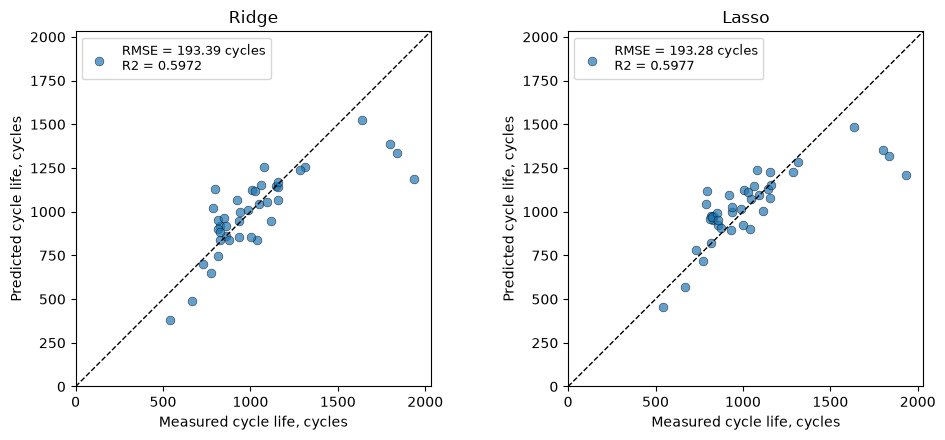

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
limits = [0, 1.05 * max(y_test.max(), predictions["Ridge: single validation"].max(),
                        predictions["Lasso: single validation"].max())]
for axis, name in zip(ax, ["Ridge: single validation", "Lasso: single validation"]):
    pred = predictions[name]
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    axis.scatter(y_test, pred, s=40, alpha=0.7, edgecolor="black", linewidth=0.4,
                 label=f"RMSE = {rmse:.2f} cycles\nR2 = {r2:.4f}")
    axis.plot(limits, limits, "k--", linewidth=1)
    axis.set(xlabel="Measured cycle life, cycles", ylabel="Predicted cycle life, cycles",
             title=name.split(":")[0], xlim=limits, ylim=limits, aspect="equal")
    axis.legend(fontsize=9)
fig.tight_layout()
plt.show()


### 10.2 Does changing the target improve the simple model?

These models use the same single input, scaler, and development batteries. Only the target transformation changes. Compare their validation and test RMSE, not just the appearance of the curves.


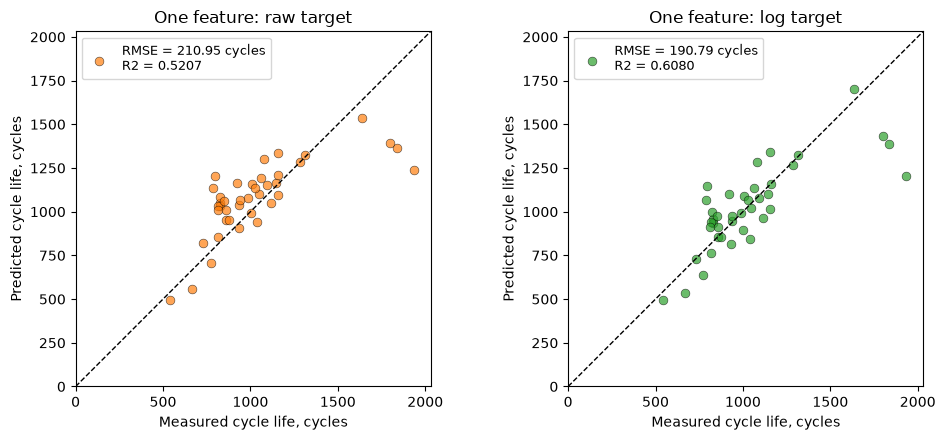

One-feature test RMSE reduction: 9.6%


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
limits = [0, 1.05 * max(y_test.max(), predictions["One feature: raw target"].max(),
                        predictions["One feature: log target"].max())]
for axis, name, color in zip(ax, ["One feature: raw target", "One feature: log target"], ["C1", "C2"]):
    pred = predictions[name]
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    axis.scatter(y_test, pred, color=color, s=40, alpha=0.7, edgecolor="black", linewidth=0.4,
                 label=f"RMSE = {rmse:.2f} cycles\nR2 = {r2:.4f}")
    axis.plot(limits, limits, "k--", linewidth=1)
    axis.set(xlabel="Measured cycle life, cycles", ylabel="Predicted cycle life, cycles",
             title=name, xlim=limits, ylim=limits, aspect="equal")
    axis.legend(fontsize=9)
fig.tight_layout()
plt.show()

raw_rmse = test_results.loc["One feature: raw target", "Test RMSE, cycles"]
log_rmse = test_results.loc["One feature: log target", "Test RMSE, cycles"]
print(f"One-feature test RMSE reduction: {100 * (raw_rmse - log_rmse) / raw_rmse:.1f}%")
